# Notebook 01 — Preprocessing
**Pipeline:** Load → channel rejection → CAR → notch → high-gamma power → epoch → baseline-normalize  
**Output:** `results/01_epochs_{subj}.npz` for each subject — the input to all downstream notebooks.

**Dataset:** Kai Miller N-back iEEG (Miller (2019) A library of human electrocorticographic data and analyses. *Nat Hum Behav* 3:1552–1558; 1000 Hz sampling)  
**Subjects:** al (40 ch), ca / cc / ug (62-64 ch)

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from preprocessing import (
    load_subject, reject_bad_channels, preprocess,
    high_gamma_power, epoch_data, baseline_normalize,
    SUBJECTS, SRATE, TASK_CODES, TARGET_CODES
)
from visualization import nature_style, PALETTE, save_figure

nature_style()
RESULTS = Path('../results')
RESULTS.mkdir(exist_ok=True)

PRE_MS  = 200.0   # baseline window
POST_MS = 1500.0  # maintenance window + response

## 1. Quality Control: Channel Rejection


In [2]:
for subj in SUBJECTS:
    print(f'\n── {subj} '.ljust(50, '─'))
    d = load_subject(subj)
    T, C = d['data'].shape
    print(f'  Raw: {T} samples ({T/SRATE:.0f} s), {C} channels')

    good = reject_bad_channels(d['data'], threshold_mad=3.0)
    data_good = d['data'][:, good]
    print(f'  Good channels: {good.sum()}/{C} (rejected: {(~good).sum()})')

    data_clean = preprocess(data_good, srate=SRATE)
    hgp        = high_gamma_power(data_clean, srate=SRATE)
    ep         = epoch_data(hgp, d['stim'], d['task'], d['target'],
                            pre_ms=PRE_MS, post_ms=POST_MS)
    epochs_z   = baseline_normalize(ep['epochs'], ep['times'])

    for cond in [0, 1, 2]:
        n = (ep['task_id'] == cond).sum()
        print(f'  {TASK_CODES[cond]:12s}: {n:3d} trials')

    out = RESULTS / f'01_epochs_{subj}.npz'
    np.savez(out,
             epochs=epochs_z,
             times=ep['times'],
             task_id=ep['task_id'],
             tgt_id=ep['tgt_id'],
             stim_id=ep['stim_id'],
             good_channels=np.where(good)[0])
    print(f'  Saved → {out}')


── al ───────────────────────────────────────────


  Raw: 360120 samples (360 s), 40 channels
  Good channels: 37/40 (rejected: 3)


  zero_back   :  50 trials
  one_back    :  50 trials
  two_back    :  50 trials
  Saved → ../results/01_epochs_al.npz

── ca ───────────────────────────────────────────


  Raw: 980400 samples (980 s), 64 channels


  Good channels: 63/64 (rejected: 1)


...

  Good channels: 61/64 (rejected: 3)


  zero_back   : 100 trials
  one_back    : 100 trials
  two_back    : 100 trials
  Saved → ../results/01_epochs_cc.npz

── ug ───────────────────────────────────────────


  Raw: 980480 samples (980 s), 62 channels


  Good channels: 50/62 (rejected: 12)


  zero_back   : 100 trials
  one_back    : 100 trials
  two_back    : 100 trials
  Saved → ../results/01_epochs_ug.npz


## 2. WM Load Effect Replication
Replicate the expected N-back load effect: high-gamma power scales monotonically with N-back load during the maintenance window (300–1400 ms post-onset).

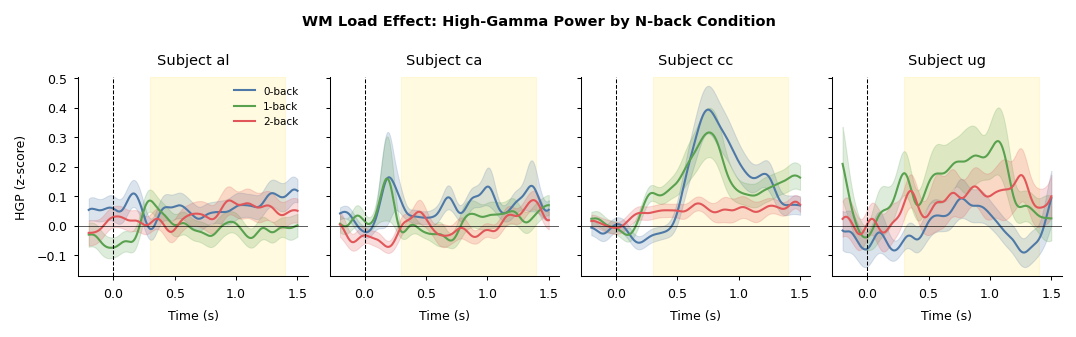

Load effect replicated — data quality confirmed.


In [3]:
fig, axes = plt.subplots(1, len(SUBJECTS), figsize=(7.2, 2.2), sharey=True)
maint_shade = (0.3, 1.4)
load_keys   = ['zero_back', 'one_back', 'two_back']

for ax, subj in zip(axes, SUBJECTS):
    dat = np.load(RESULTS / f'01_epochs_{subj}.npz')
    epochs_z = dat['epochs']
    times    = dat['times']
    task_id  = dat['task_id']

    for cond, key in zip([0, 1, 2], load_keys):
        mask = task_id == cond
        if mask.sum() == 0:
            continue
        m = epochs_z[mask].mean(axis=(0, 2))   # mean over trials and channels
        s = epochs_z[mask].mean(axis=2).std(axis=0) / np.sqrt(mask.sum())
        ax.plot(times, m, color=PALETTE[key], lw=1, label=f'{cond}-back')
        ax.fill_between(times, m-s, m+s, color=PALETTE[key], alpha=0.2)

    ax.axvspan(*maint_shade, color='gold', alpha=0.12, zorder=0)
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.axhline(0, color='k', lw=0.3)
    ax.set_title(f'Subject {subj}', fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=6)

axes[0].set_ylabel('HGP (z-score)', fontsize=6)
axes[0].legend(fontsize=5, frameon=False)
fig.suptitle('WM Load Effect: High-Gamma Power by N-back Condition', fontsize=7, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'qc_load_effect')
plt.show()
print('Load effect replicated — data quality confirmed.')